In [1]:
packages <- c("dplyr", "ggplot2", "patchwork", "RColorBrewer", "cowplot", "magick", "grid")
for (pkg in packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(pkg, character.only = TRUE)
        )
    )
}

In [2]:
# Get the current working directory and find Git root
find_git_root <- function() {
    # Get current working directory
    cwd <- getwd()
    
    # Check if current directory has .git
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    
    # If not, search parent directories
    current_path <- cwd
    while (dirname(current_path) != current_path) {  # While not at root
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    
    # If no Git root found, stop with error
    stop("No Git root directory found.")
}

# Find the Git root directory
root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")
source(file.path(root_dir, "utils", "r_plot_themes.r"))

Git root directory: /home/lippincm/Documents/NF1_organoid_profile_analysis 


In [3]:
data_to_plot_file_path <- file.path(root_dir, "/1.EDA/results/correlation/3D_sc_correlation_pairs_sc_norm_agg_with_meta_and_viability.parquet")
correlation_viability_df <- arrow::read_parquet(data_to_plot_file_path)
figures_base_dir <- file.path(root_dir, "1.EDA", "figures")

In [4]:
high_correlation_cutoff <- 0.9
low_correlation_cutoff <- 0.1
similar_viability_difference_cutoff <- 0.1
dissimilar_viability_difference_cutoff <- 0.9

quadrant_palette <- c(
  "top_left" = "#379400",
  "top_right" = "#94764D",
  "bottom_left" = "#005D94",
  "bottom_right" = "#910094",
  "middle" = "#8b8b8b"
)
# what each quadrant means, biologically: does correlation (morphology)
# and/or viability distinguish the pair? Used as title tiles above each
# example montage image below (not a legend), so the figure reads without
# a legend key that just says "top_left" etc.
quadrant_labels <- c(
  "top_left" = "Viability and morphology distinguishable",
  "top_right" = "Viability distinguishable",
  "bottom_left" = "Morphology distinguishable",
  "bottom_right" = "Not distinguishable",
  "middle" = "Middle"
)

# --- bivariate point color: a 2D (4-corner) bilinear blend, so a point's
# color shows where it sits on BOTH axes at once, not just which quadrant it
# falls in. Y (viability difference) selects the hue family -- cyan at 0,
# purple at 1 -- and X (correlation) selects lightness within that family --
# dark at the minimum observed correlation, light at correlation = 1.
corr_min <- min(correlation_viability_df$correlation, na.rm = TRUE)
corr_max <- 1  # correlation is bounded above by 1

correlation_viability_df <- correlation_viability_df %>%
  mutate(
    corr_norm = pmin(pmax((correlation - corr_min) / (corr_max - corr_min), 0), 1),
    viability_norm = pmin(pmax(group1_group2_viability_diff, 0), 1)
  )

corner_dark_cyan    <- c(0, 102, 102)    # bottom-left:  low corr,  viability = 0
corner_light_cyan   <- c(204, 255, 255)  # bottom-right: corr = 1,  viability = 0
corner_light_purple <- c(217, 179, 255)  # top-right:    corr = 1,  viability = 1
corner_dark_purple  <- c(75, 0, 130)     # indigo, used only to build the top-left mix below
corner_top_left     <- (corner_dark_cyan + corner_dark_purple) / 2  # top-left: low corr, viability = 1 -- dark cyan/purple mix

u <- correlation_viability_df$corr_norm
v <- correlation_viability_df$viability_norm
bilinear <- function(channel) {
  (1 - u) * (1 - v) * corner_dark_cyan[channel] +
    u * (1 - v) * corner_light_cyan[channel] +
    (1 - u) * v * corner_top_left[channel] +
    u * v * corner_light_purple[channel]
}

correlation_viability_df$point_color <- rgb(
  bilinear(1), bilinear(2), bilinear(3), maxColorValue = 255
)

width <- 6
height <- 6
options(repr.plot.width = width, repr.plot.height = height)
correlation_viability_plot <- ggplot(
  correlation_viability_df,
  aes(x = correlation, y = group1_group2_viability_diff)
) +
  geom_point(aes(color = point_color), alpha = 0.5, size = 1.5) +
  scale_color_identity() +
  geom_density_2d(color = "black", linewidth = 0.3, alpha = 0.6) +
  labs(
    x = "Correlation between samples",
    y = "abs(Viability Difference) between samples",
  ) +
  theme_minimal() +
  theme(legend.position = "none")


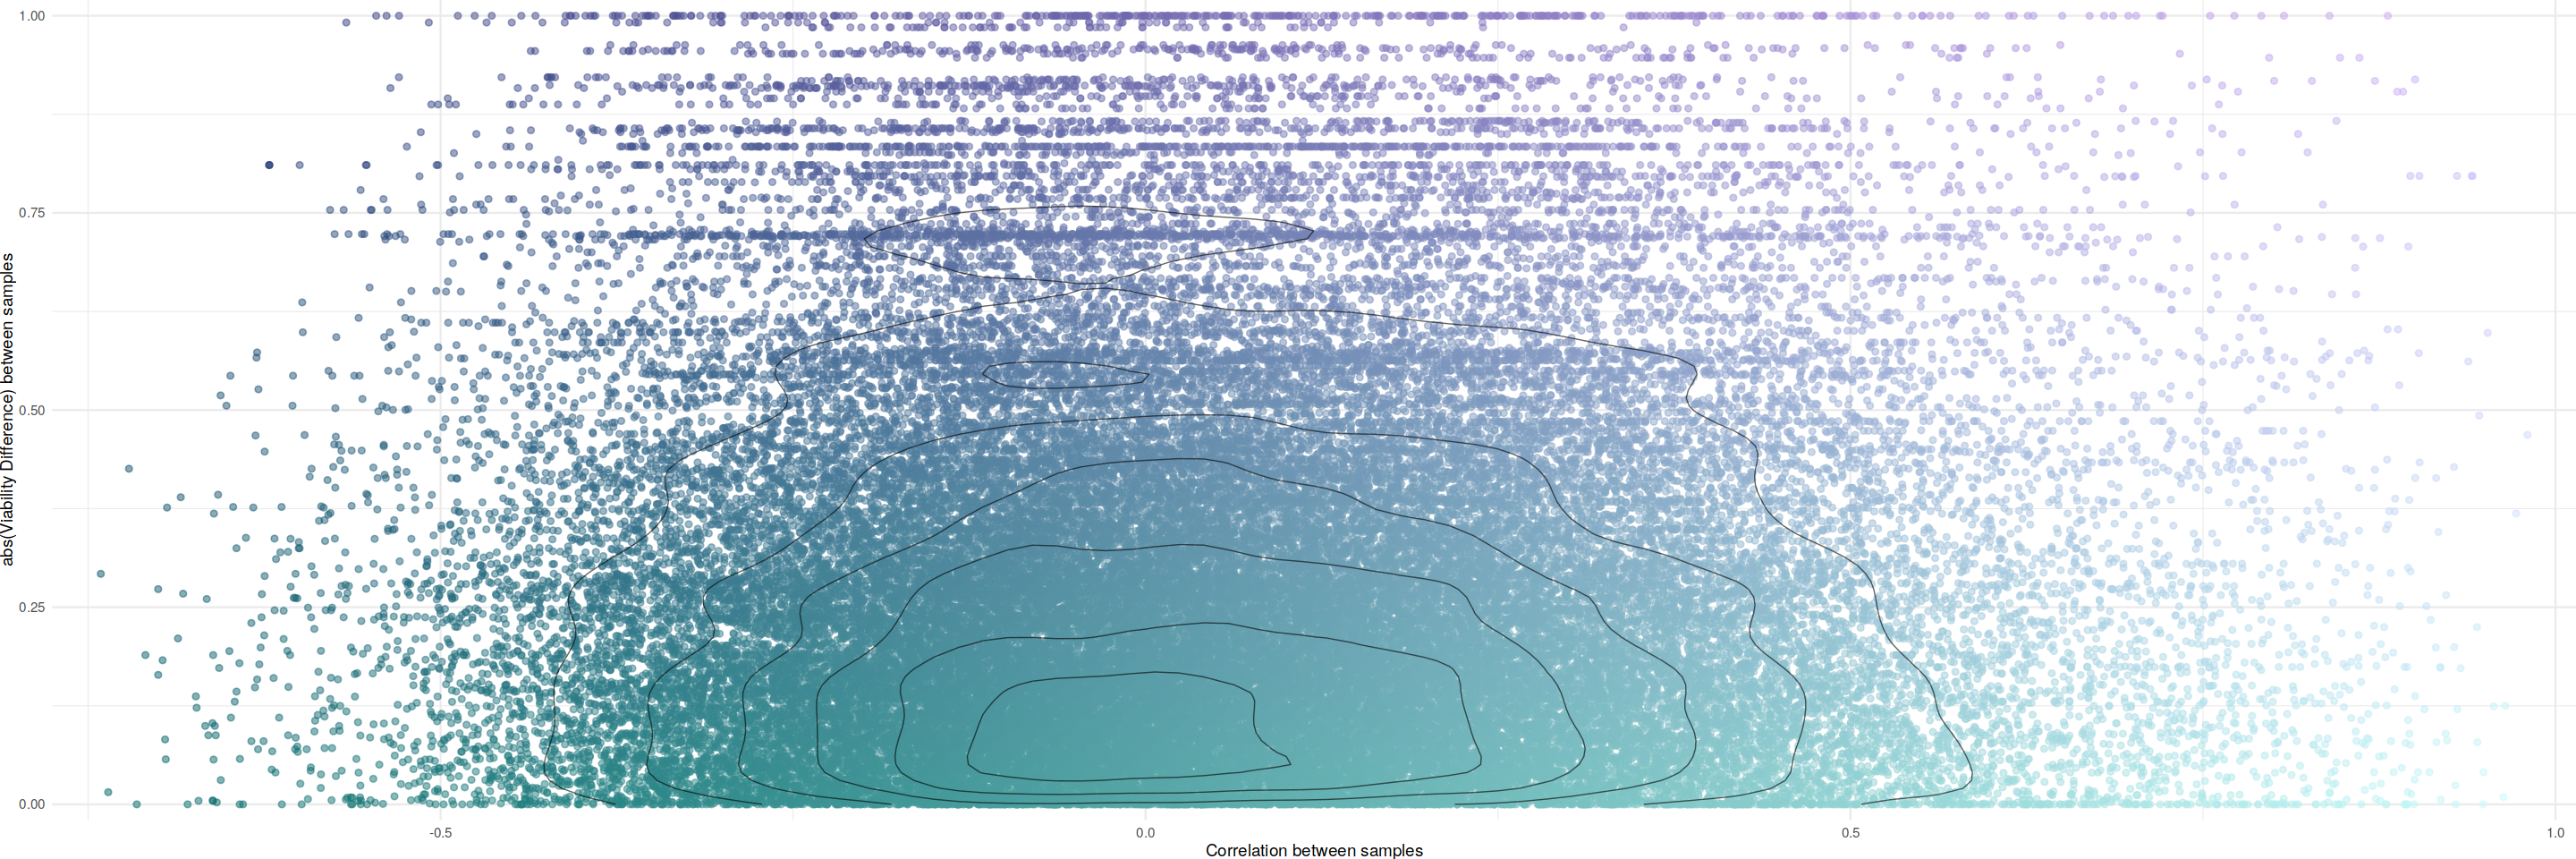

In [5]:
height <- 8
width <- 24
options(repr.plot.width = width, repr.plot.height = height)

p_base <- correlation_viability_plot +
  scale_x_continuous(expand = expansion(mult = 0.02)) +
  scale_y_continuous(expand = expansion(mult = 0.02)) +
  theme(
    plot.margin = margin(0, 0, 0, 0),
    plot.background = element_rect(fill = "white", color = NA)
  )

img_paths <- list(
  top_left     = file.path(root_dir, "1.EDA/figures/montages/low_correlation_dissimilar_viability/NF0014_T1__E7__Cabozantinib__1__NF0014_T2__G2__Staurosporine__10_corr-0-333_viabilitydiff1-000.png"),
  top_right    = file.path(root_dir, "1.EDA/figures/montages/high_correlation_dissimilar_viability/NF0014_T1__G11__Staurosporine__10__NF0014_T1__G6__Ketotifen__1_corr0-847_viabilitydiff0-947.png"),
  bottom_left  = file.path(root_dir, "1.EDA/figures/montages/low_correlation_similar_viability/NF0021_T1__F4__DMSO__1__NF0037_T1__G10__Selumetinib__1_corr-0-379_viabilitydiff0-047.png"),
  bottom_right = file.path(root_dir, "1.EDA/figures/montages/high_correlation_similar_viability/NF0014_T2__G10__Selumetinib__1__NF0035_T1__F6__Nilotinib__1_corr0-945_viabilitydiff0-079.png")
)

# resize to fill the box, then add a colored border matching the quadrant
# (reuses quadrant_palette defined above, for the scatterplot legend)
target_px <- "600x300!"
border_px <- "12x12"  # thickness of the colored outline

imgs <- lapply(names(img_paths), function(q) {
  img <- image_resize(image_read(img_paths[[q]]), target_px)
  image_border(img, color = quadrant_palette[[q]], geometry = border_px)
})
names(imgs) <- names(img_paths)

# --- arrow endpoints, taken from the correlation/viability_diff values
# encoded in each montage's own filename (see script 5a), rather than a
# hand-guessed canvas position -- so an arrow always points at the exact
# point it was picked from.
# script 5a writes the decimal point as "-" (e.g. "corr0-821"), not "." --
# a "." anywhere but right before the real extension breaks tools that read
# the extension as everything after the first "." in the filename. Convert
# back to a normal decimal string ("-?123-456" -> "-?123.456") before
# parsing as numeric.
dash_decimal_to_numeric <- function(x) {
  as.numeric(sub("^(-?[0-9]+)-([0-9]+)$", "\\1.\\2", x))
}

extract_coord_from_path <- function(path) {
  fname <- basename(path)
  corr_str <- regmatches(fname, regexpr("(?<=_corr)-?[0-9]+-[0-9]+", fname, perl = TRUE))
  viab_str <- regmatches(fname, regexpr("(?<=_viabilitydiff)-?[0-9]+-[0-9]+", fname, perl = TRUE))
  if (length(corr_str) == 0 || length(viab_str) == 0) {
    stop(sprintf(
      "Could not find '_corr<value>_viabilitydiff<value>' in filename: %s -- regenerate montages with the current script 5a.",
      fname
    ))
  }
  list(correlation = dash_decimal_to_numeric(corr_str), viability_diff = dash_decimal_to_numeric(viab_str))
}

# The actual plotted axis range (post-expansion, i.e. what's really at the
# panel edges) -- not the raw data min/max, which would be slightly
# narrower than what's rendered and throw off the mapping below. Built from
# p_base (not correlation_viability_plot), since p_base overrides the
# expansion (mult = 0.02) and is what's actually placed in the canvas.
built_ranges <- ggplot_build(p_base)$layout$panel_params[[1]]
corr_range <- built_ranges$x.range
viability_range <- built_ranges$y.range

# Finds where the ggplot PANEL itself (excluding axis titles/tick labels,
# which eat real space -- left/bottom margins are ~5-8% of the box, not 0%)
# sits within a box of the given physical size. Needed because
# draw_plot(p_base, x=0.30, y=0, width=0.40, height=1) below places the
# *whole* plot (panel + axis text/titles) into that box -- the data area
# only fills part of it, so mapping data coordinates straight onto the box
# (assuming the panel = the whole box) puts arrows in the wrong place.
# Verified against known data points: a canvas position computed this way
# lands exactly on top of the same point marked in-plot via annotate().
get_panel_box_fraction <- function(plot, box_width_in, box_height_in) {
  g <- ggplotGrob(plot)
  panel_idx <- which(g$layout$name == "panel")
  panel_row <- g$layout$t[panel_idx]
  panel_col <- g$layout$l[panel_idx]

  widths_in <- convertWidth(g$widths, "in", valueOnly = TRUE)
  heights_in <- convertHeight(g$heights, "in", valueOnly = TRUE)
  is_null_width <- vapply(g$widths, function(u) grepl("null", as.character(u)), logical(1))
  is_null_height <- vapply(g$heights, function(u) grepl("null", as.character(u)), logical(1))

  # "null" (flexible) columns/rows convert to 0 in isolation -- their real
  # size is whatever's left after subtracting all the fixed-size ones from
  # the total box size
  resolved_widths_in <- widths_in
  resolved_widths_in[is_null_width] <- (box_width_in - sum(widths_in[!is_null_width])) / sum(is_null_width)
  resolved_heights_in <- heights_in
  resolved_heights_in[is_null_height] <- (box_height_in - sum(heights_in[!is_null_height])) / sum(is_null_height)

  left_in <- sum(resolved_widths_in[seq_len(panel_col - 1)])
  right_in <- left_in + resolved_widths_in[panel_col]
  top_in <- sum(resolved_heights_in[seq_len(panel_row - 1)])
  bottom_in <- top_in + resolved_heights_in[panel_row]

  list(
    left = left_in / box_width_in,
    right = right_in / box_width_in,
    bottom = 1 - (bottom_in / box_height_in),  # npc y is bottom-up; gtable rows are top-down
    top = 1 - (top_in / box_height_in)
  )
}

panel_box <- get_panel_box_fraction(p_base, box_width_in = width * 0.40, box_height_in = height * 1)

# maps a (correlation, viability_diff) data point to its position inside the
# scatterplot's canvas box (draw_plot(p_base, x = 0.30, y = 0, width = 0.40,
# height = 1) below), via the panel's actual position within that box
data_to_canvas <- function(correlation_value, viability_diff_value) {
  norm_x <- (correlation_value - corr_range[1]) / diff(corr_range)
  norm_y <- (viability_diff_value - viability_range[1]) / diff(viability_range)
  panel_x <- panel_box$left + norm_x * (panel_box$right - panel_box$left)
  panel_y <- panel_box$bottom + norm_y * (panel_box$top - panel_box$bottom)
  list(x = 0.30 + 0.40 * panel_x, y = 0 + 1 * panel_y)
}

arrow_targets <- lapply(img_paths, function(p) {
  coord <- extract_coord_from_path(p)
  data_to_canvas(coord$correlation, coord$viability_diff)
})

p_base

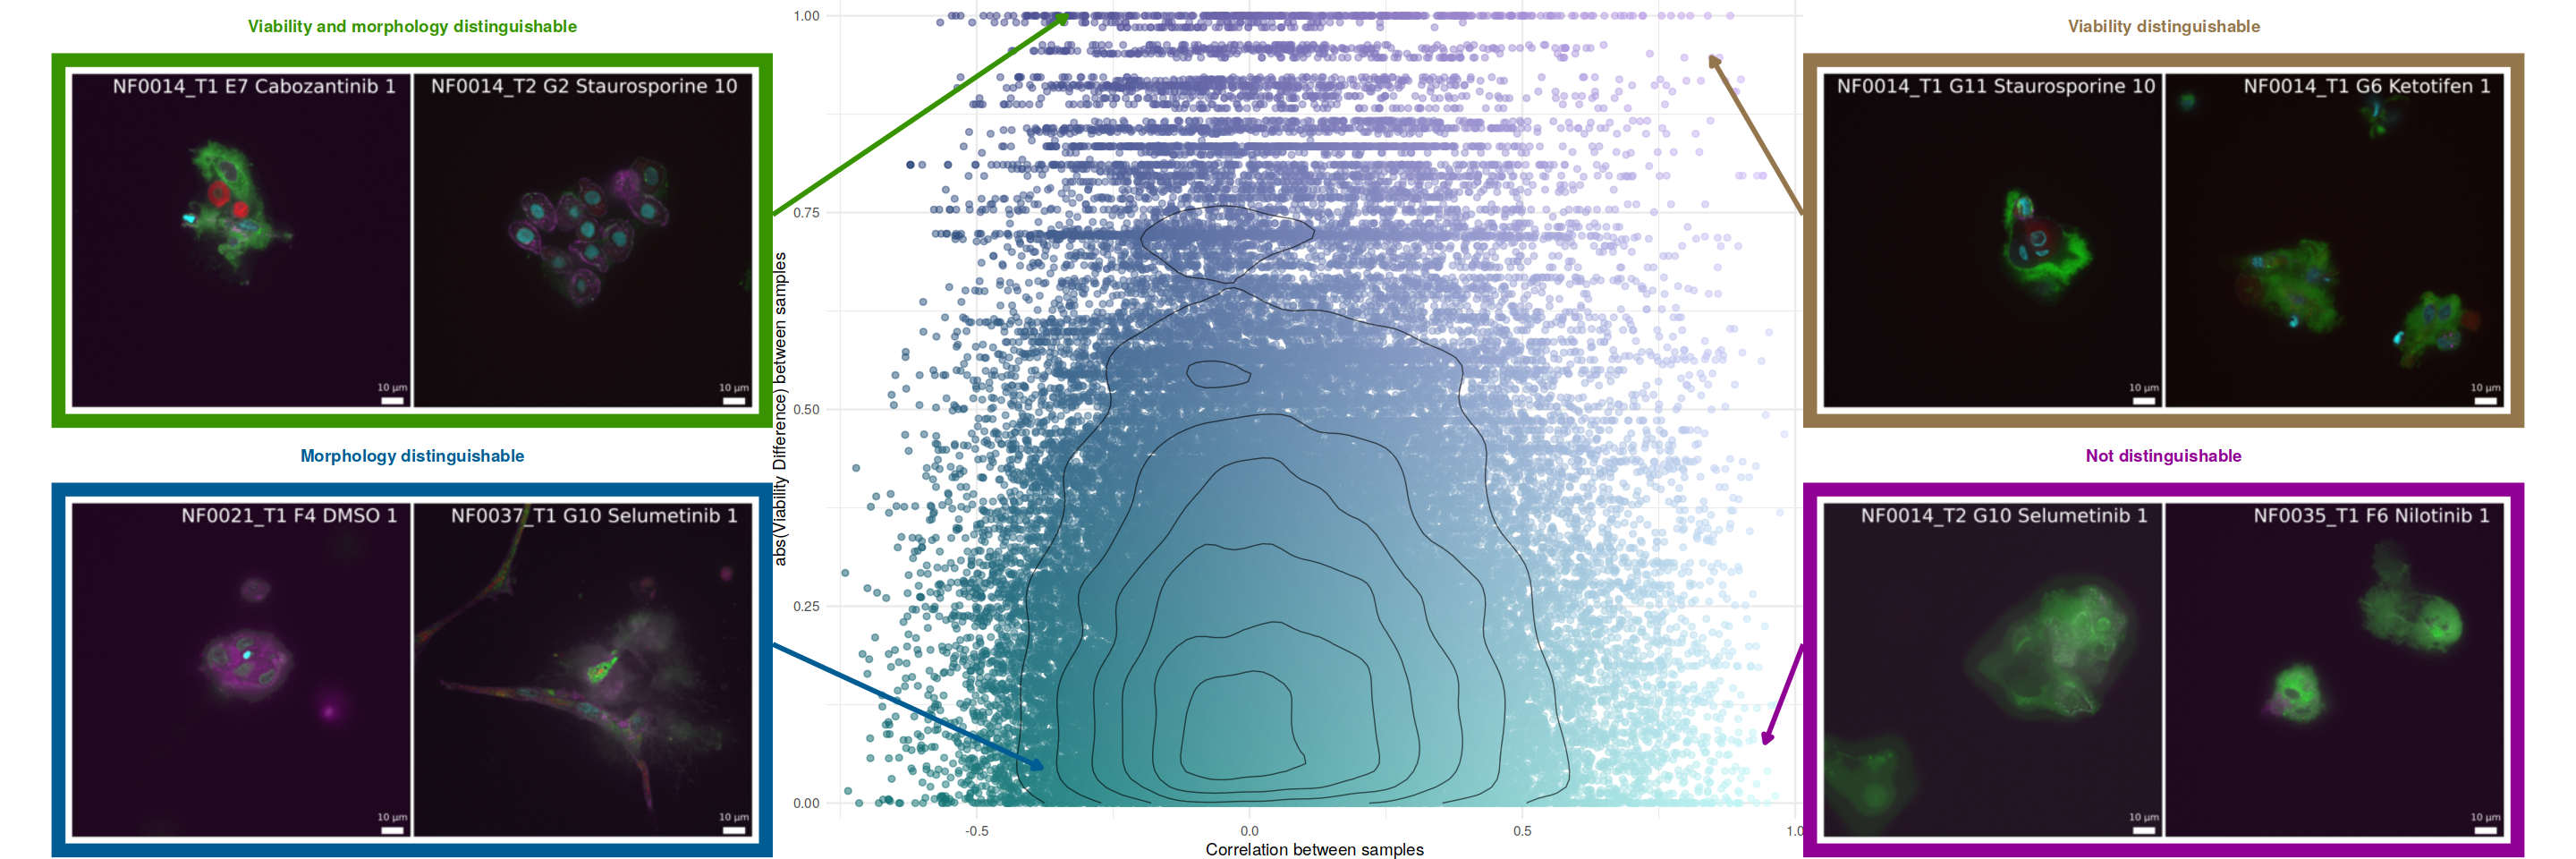

In [6]:

canvas <- ggdraw() +
  draw_plot(p_base, x = 0.30, y = 0, width = 0.40, height = 1) +

  # images shrunk to height 0.44 (from 0.5) to leave a strip above each for
  # its title tile
  draw_image(imgs$top_left,     x = 0.02, y = 0.50, width = 0.28, height = 0.44) +
  draw_image(imgs$bottom_left,  x = 0.02, y = 0.00, width = 0.28, height = 0.44) +
  draw_image(imgs$top_right,    x = 0.70, y = 0.50, width = 0.28, height = 0.44) +
  draw_image(imgs$bottom_right, x = 0.70, y = 0.00, width = 0.28, height = 0.44) +

  # title tiles, colored to match each image's border, replacing what used
  # to be a separate legend keyed by "top_left"/"top_right"/etc.
  draw_label(quadrant_labels[["top_left"]], x = 0.16, y = 0.97,
             size = 11, fontface = "bold", color = quadrant_palette[["top_left"]]) +
  draw_label(quadrant_labels[["bottom_left"]], x = 0.16, y = 0.47,
             size = 11, fontface = "bold", color = quadrant_palette[["bottom_left"]]) +
  draw_label(quadrant_labels[["top_right"]], x = 0.84, y = 0.97,
             size = 11, fontface = "bold", color = quadrant_palette[["top_right"]]) +
  draw_label(quadrant_labels[["bottom_right"]], x = 0.84, y = 0.47,
             size = 11, fontface = "bold", color = quadrant_palette[["bottom_right"]]) +

  # colored arrows from each image to the exact point it was picked from
  # (arrow_targets, computed above from each filename's encoded
  # correlation/viability_diff), matching the border/quadrant color so the
  # source is unambiguous
  draw_line(x = c(0.30, arrow_targets$top_left$x), y = c(0.75, arrow_targets$top_left$y),
            color = quadrant_palette[["top_left"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.30, arrow_targets$bottom_left$x), y = c(0.25, arrow_targets$bottom_left$y),
            color = quadrant_palette[["bottom_left"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.70, arrow_targets$top_right$x), y = c(0.75, arrow_targets$top_right$y),
            color = quadrant_palette[["top_right"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed")) +
  draw_line(x = c(0.70, arrow_targets$bottom_right$x), y = c(0.25, arrow_targets$bottom_right$y),
            color = quadrant_palette[["bottom_right"]], size = 1.2,
            arrow = arrow(length = unit(0.08, "inches"), type = "closed"))

ggsave(
  filename = file.path(figures_base_dir, "correlation_vs_viability_with_examples.png"),
  plot = canvas,
  width = width,
  height = height,
  dpi = 600,
  bg = "white"
)
canvas